\# DBSCAN Clustering

In [ ]:
!pip install kagglehub -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

## 1. Load Data

In [ ]:
import kagglehub

path = kagglehub.dataset_download("fivethirtyeight/uber-pickups-in-new-york-city")
df = pd.read_csv(os.path.join(path, 'uber-raw-data-jul14.csv'))
df.head()

100%|██████████| 109M/109M [00:01<00:00, 110MB/s] 

Extracting files...


,Date/Time,Lat,Lon,Base
0,7/1/2014 0:03:00,40.7586,-73.9706,B02512
1,7/1/2014 0:05:00,40.7605,-73.9994,B02512
2,7/1/2014 0:06:00,40.7320,-73.9999,B02512
3,7/1/2014 0:09:00,40.7635,-73.9793,B02512
4,7/1/2014 0:20:00,40.7204,-74.0047,B02512


## 2. Prepare Features

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace('/', '_', regex=False)
df.rename(columns={'date_time': 'datetime'}, inplace=True)

df = df[['lat', 'lon', 'datetime', 'base']].dropna()
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

df['lat_n'] = (df['lat'] - df['lat'].mean()) / df['lat'].std()
df['lon_n'] = (df['lon'] - df['lon'].mean()) / df['lon'].std()

X = df[['lat_n', 'lon_n']].values
print(f'Ready: {X.shape}')

Ready: (5000, 2)


## 3. DBSCAN from Scratch

In [ ]:
class DBSCAN:

    def __init__(self, eps=0.5, min_pts=5):
        self.eps     = eps
        self.min_pts = min_pts

    def get_neighbors(self, X, i):
        return [j for j in range(len(X))
                if np.sqrt(np.sum((X[i] - X[j]) ** 2)) <= self.eps]

    def grow_cluster(self, X, labels, i, neighbors, cid):
        labels[i] = cid
        q = deque(neighbors)
        while q:
            n = q.popleft()
            if labels[n] == -1:
                labels[n] = cid
            if labels[n] != 0:
                continue
            labels[n] = cid
            nn = self.get_neighbors(X, n)
            if len(nn) >= self.min_pts:
                q.extend(nn)

    def fit(self, X):
        labels = np.zeros(len(X), dtype=int)
        cid = 0
        for i in range(len(X)):
            if labels[i] != 0:
                continue
            nb = self.get_neighbors(X, i)
            if len(nb) < self.min_pts:
                labels[i] = -1
            else:
                cid += 1
                self.grow_cluster(X, labels, i, nb, cid)
        return labels

    def get_point_types(self, X, labels):
        types = np.where(labels == -1, 'NOISE', 'BORDER')
        for i in range(len(X)):
            if labels[i] != -1 and len(self.get_neighbors(X, i)) >= self.min_pts:
                types[i] = 'CORE'
        return types

## 4. Visualisation

In [ ]:
def show_types(X, types, eps, mp):
    colors  = {'CORE': '#2196F3', 'BORDER': '#4CAF50', 'NOISE': '#F44336'}
    markers = {'CORE': 'o',       'BORDER': 's',       'NOISE': 'x'}
    sizes   = {'CORE': 20,        'BORDER': 20,         'NOISE': 10}
    fig, ax = plt.subplots(figsize=(8, 6))
    for t in ['CORE', 'BORDER', 'NOISE']:
        m = types == t
        ax.scatter(X[m,1], X[m,0], c=colors[t], marker=markers[t],
                   s=sizes[t], alpha=0.6, label=f'{t} ({m.sum()})')
    ax.set_title(f'Point Types  |  eps={eps}, minPts={mp}')
    ax.set_xlabel('Longitude (normalised)')
    ax.set_ylabel('Latitude (normalised)')
    ax.legend()
    plt.tight_layout()
    plt.show()


def show_clusters(X, labels, eps, mp):
    unique     = np.unique(labels)
    n_clusters = len(unique[unique != -1])
    n_noise    = (labels == -1).sum()
    cmap       = plt.cm.get_cmap('tab20', max(n_clusters, 1))
    fig, ax    = plt.subplots(figsize=(8, 6))
    noise      = labels == -1
    if noise.any():
        ax.scatter(X[noise,1], X[noise,0], c='#F44336', s=8,
                   alpha=0.4, marker='x', label='Noise')
    for cid in unique[unique != -1]:
        m = labels == cid
        ax.scatter(X[m,1], X[m,0], c=[cmap((cid-1)%20)], s=15,
                   alpha=0.7, label=f'Cluster {cid}' if n_clusters <= 10 else None)
    ax.set_title(f'Clusters  |  eps={eps}, minPts={mp}  →  {n_clusters} cluster(s), {n_noise} noise')
    ax.set_xlabel('Longitude (normalised)')
    ax.set_ylabel('Latitude (normalised)')
    if n_clusters <= 10:
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 5. Run Experiments

eps=0.1, minPts=5


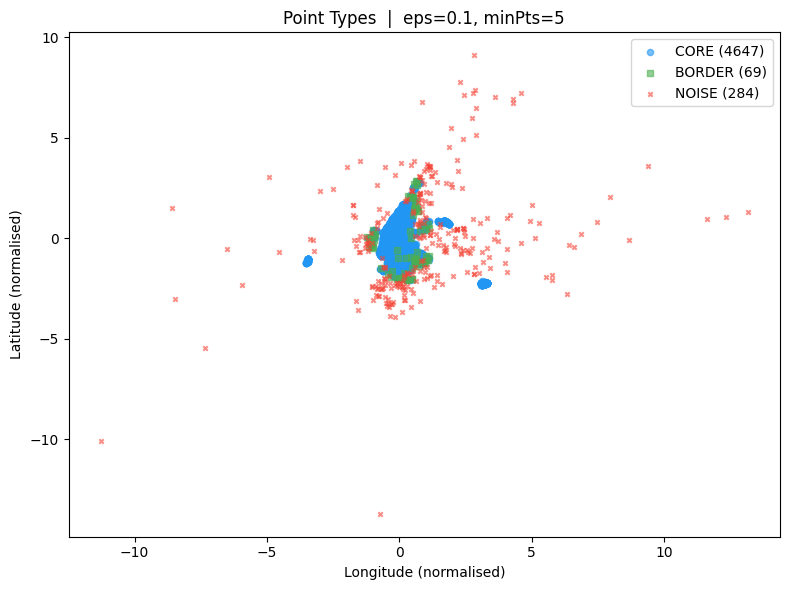

/tmp/ipykernel_17182/152637761.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = plt.cm.get_cmap('tab20', max(n_clusters, 1))


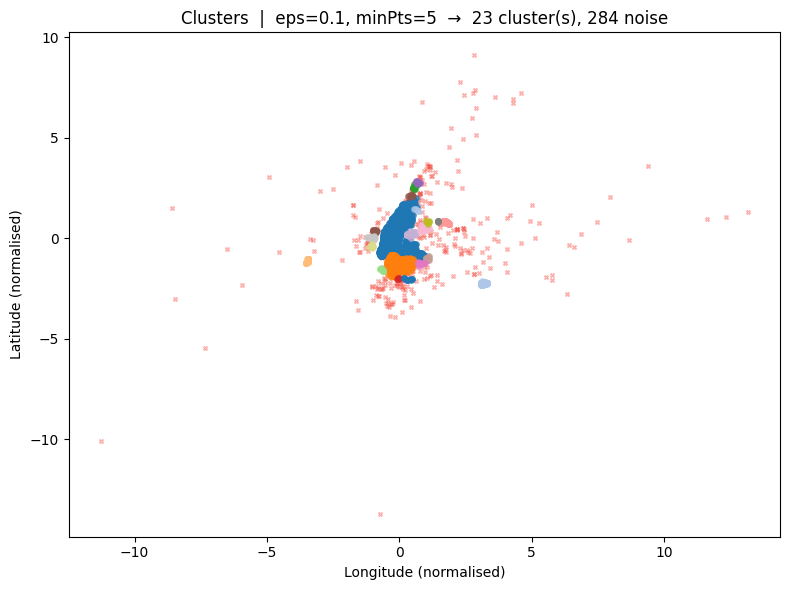

eps=0.1, minPts=10


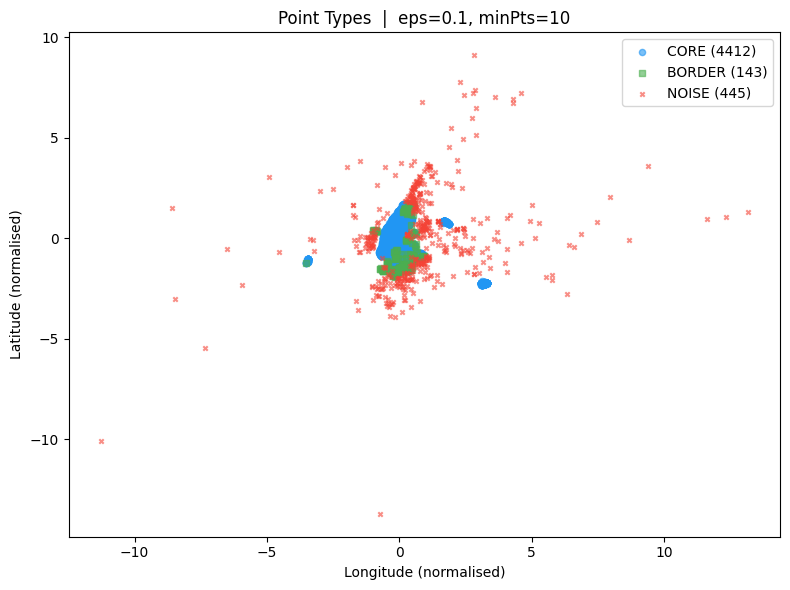

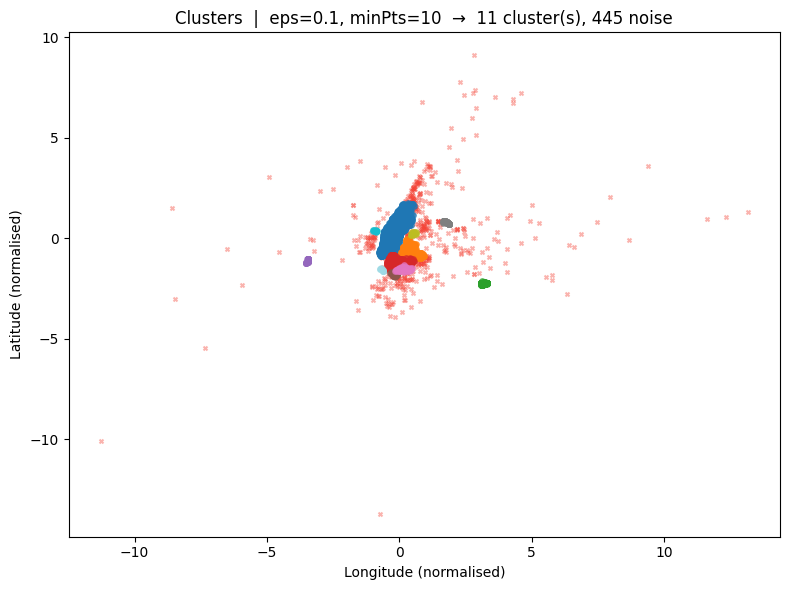

eps=0.1, minPts=20


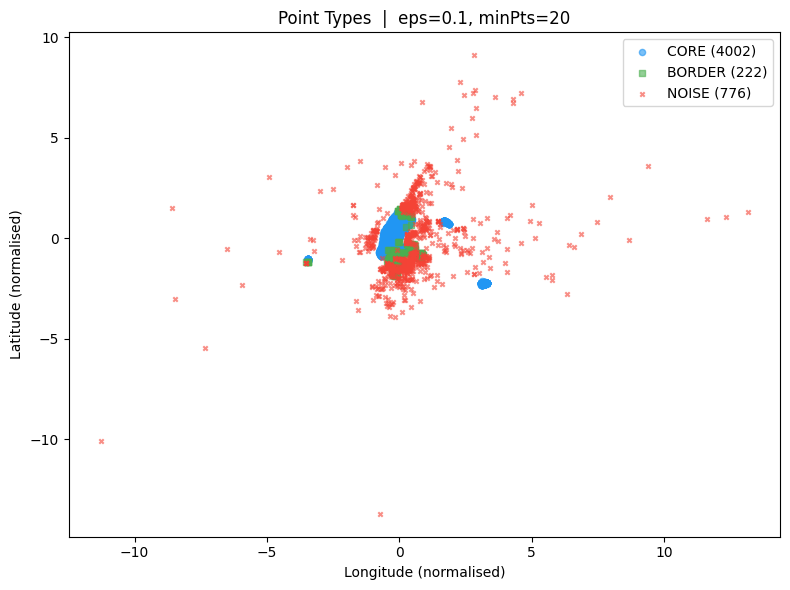

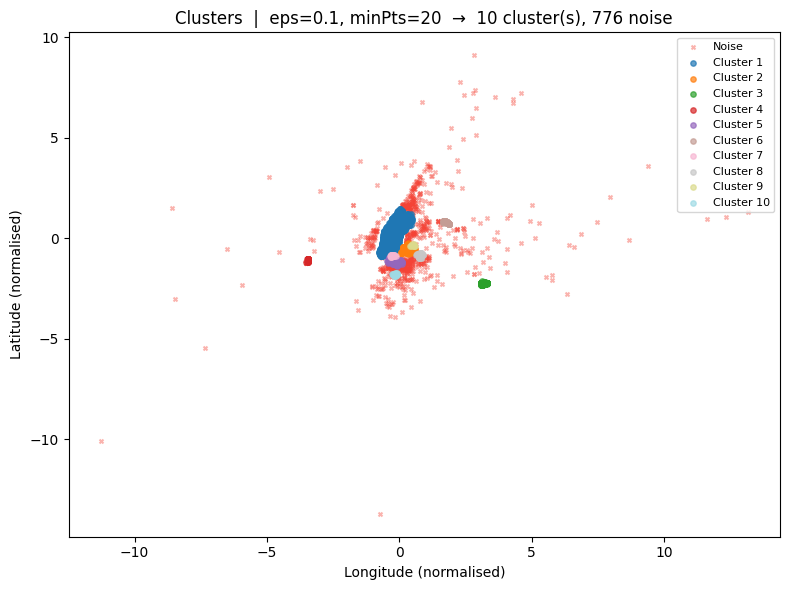

eps=0.3, minPts=5


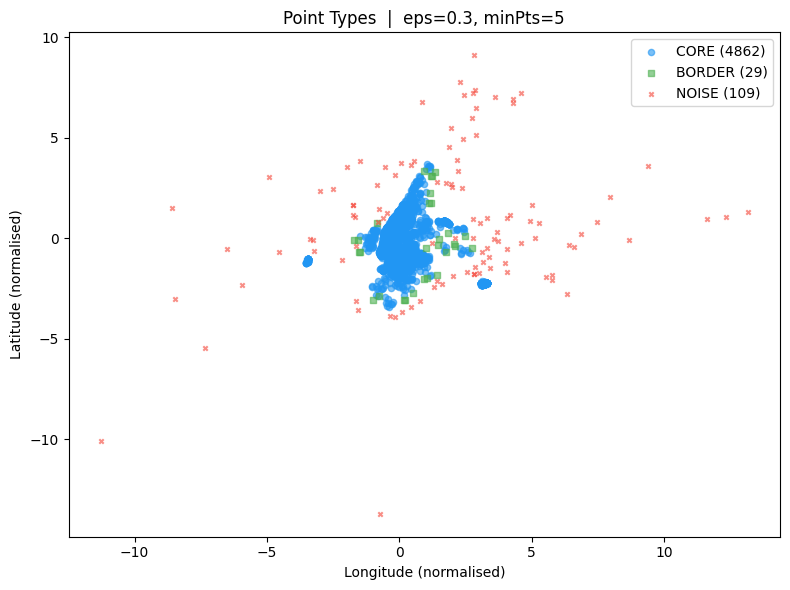

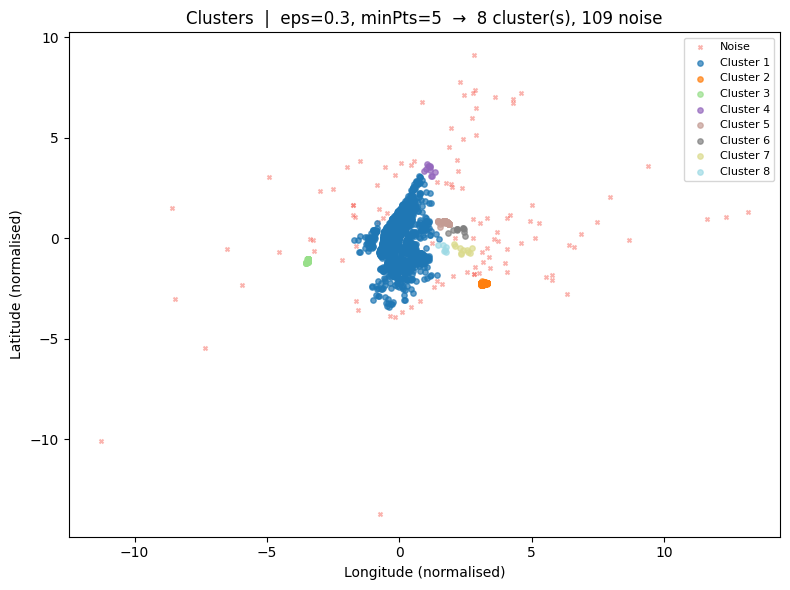

eps=0.3, minPts=10


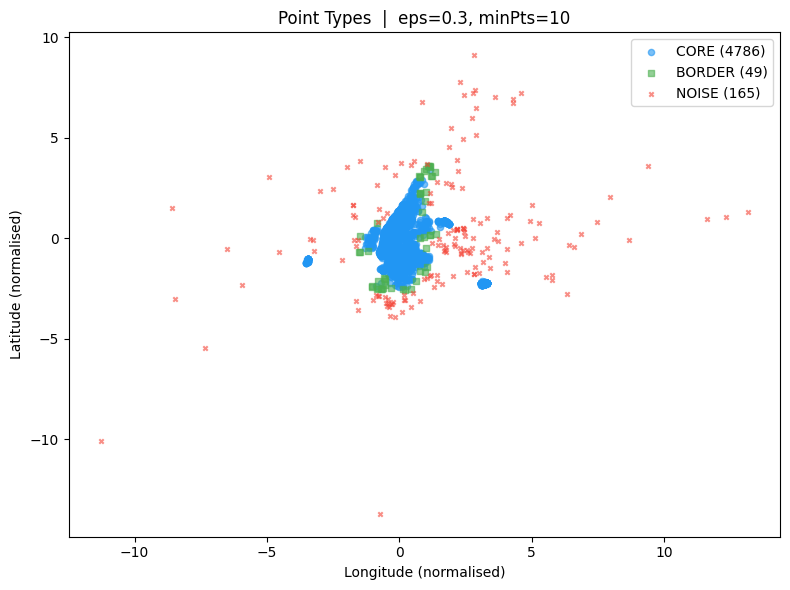

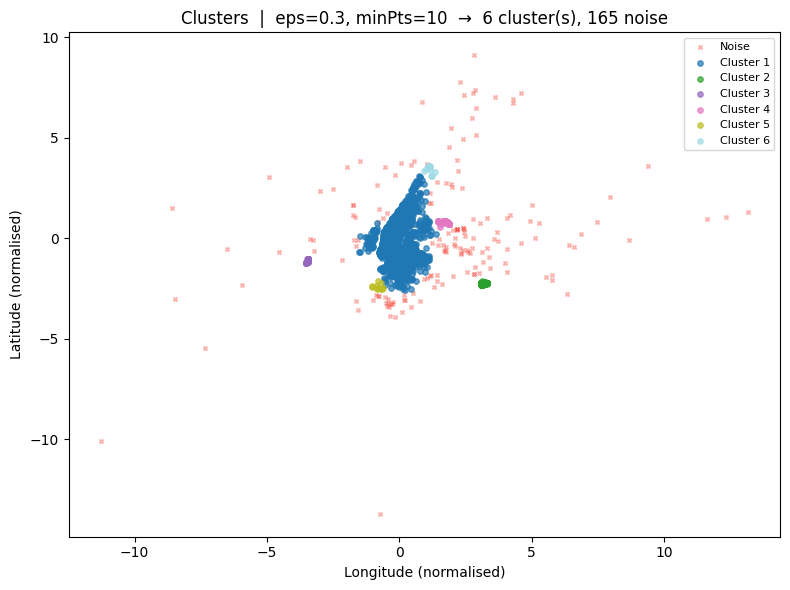

eps=0.3, minPts=20


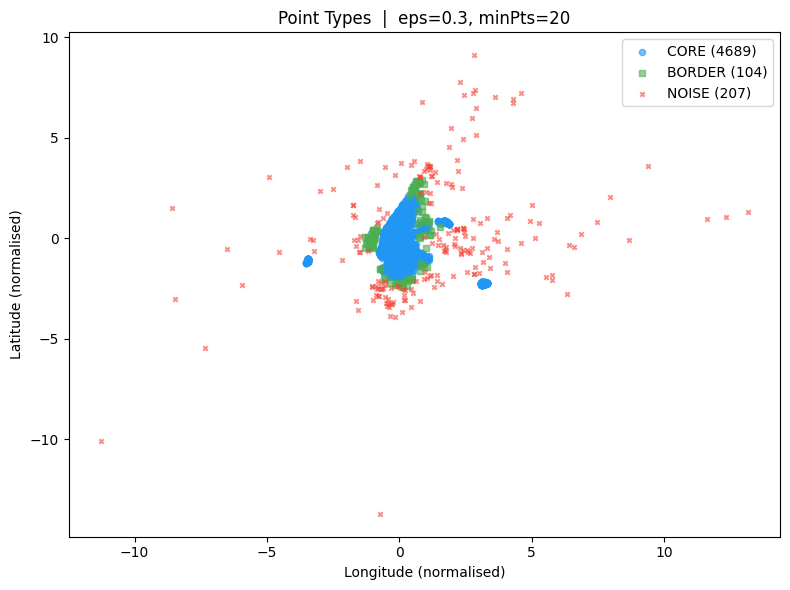

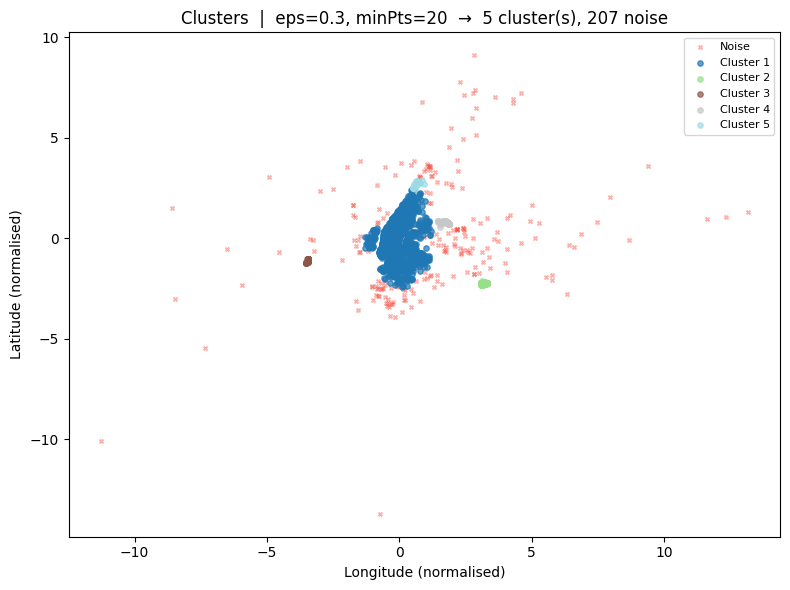

eps=0.5, minPts=5


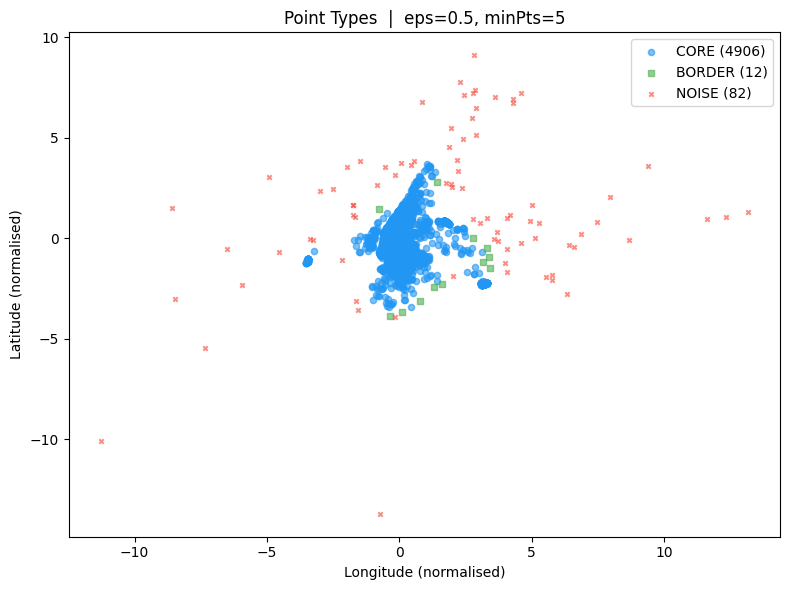

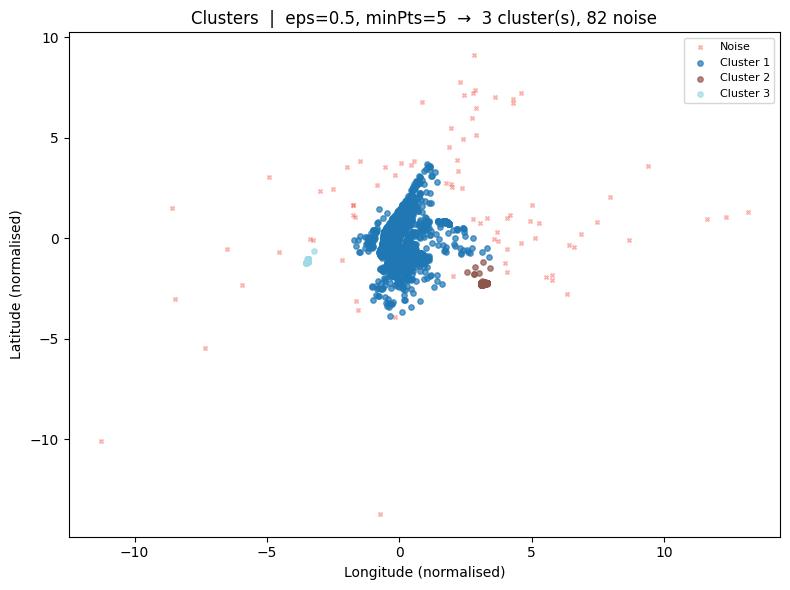

eps=0.5, minPts=10


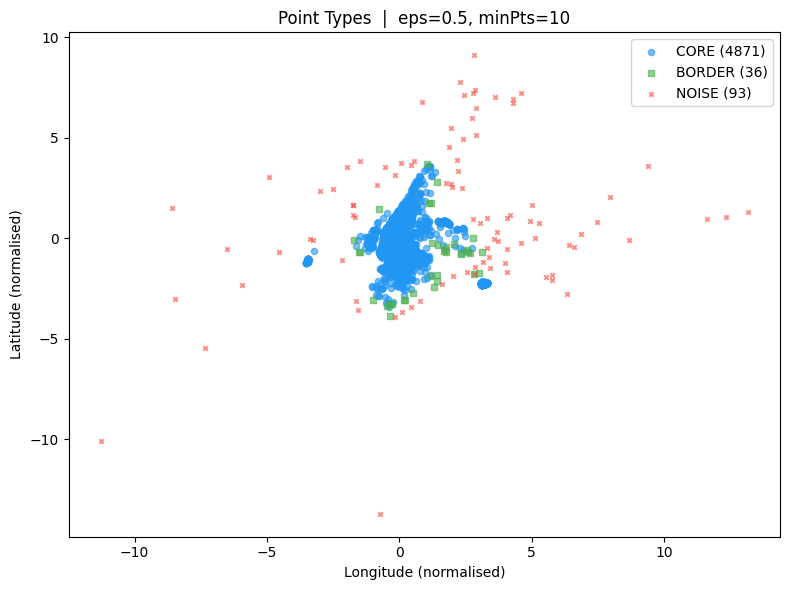

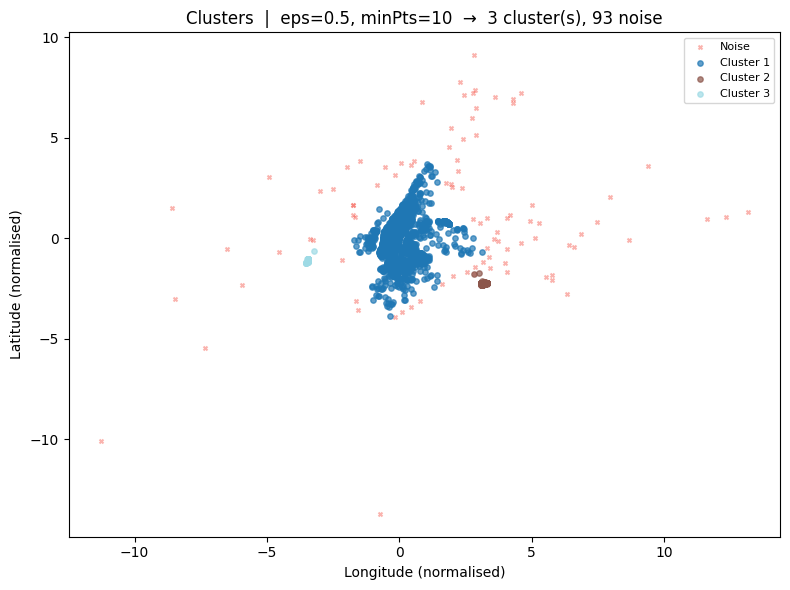

eps=0.5, minPts=20


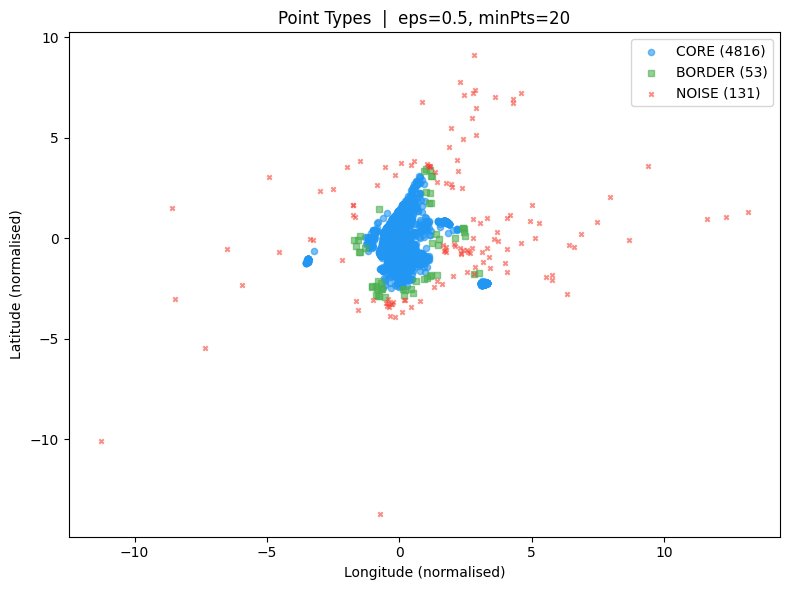

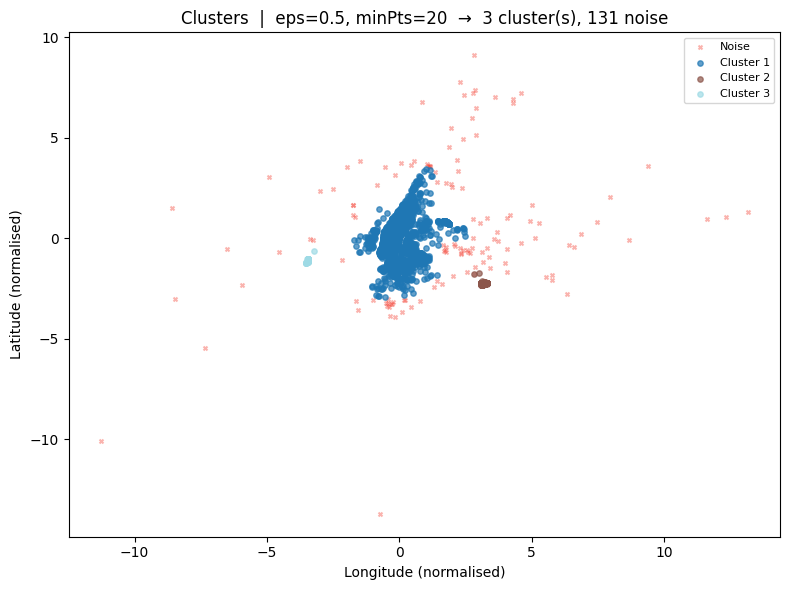

eps=1.0, minPts=5


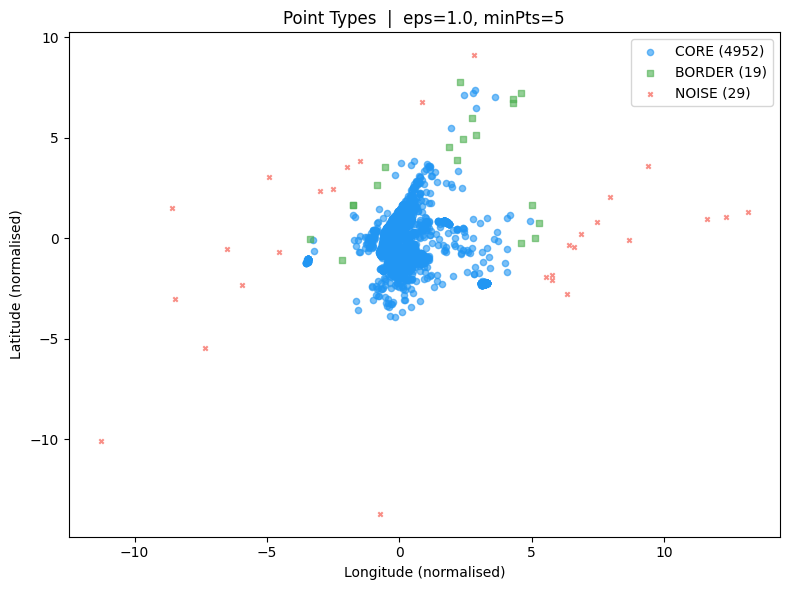

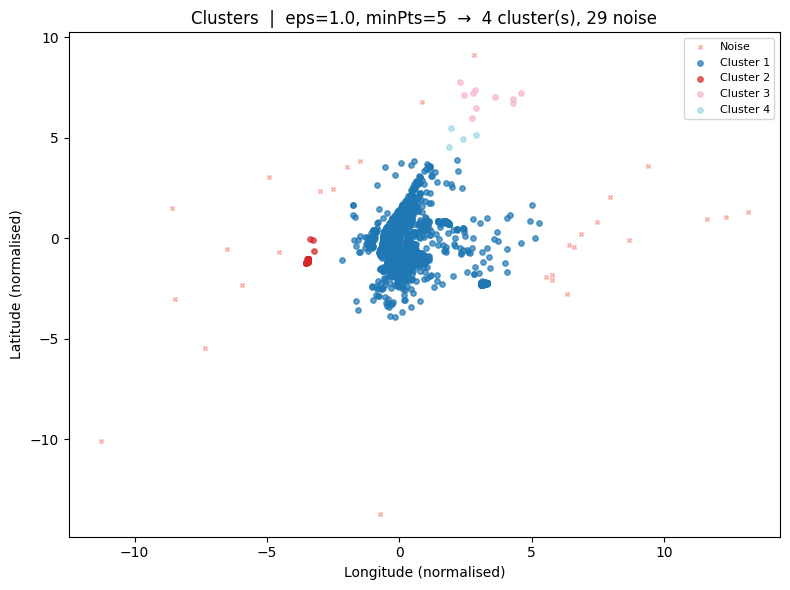

eps=1.0, minPts=10


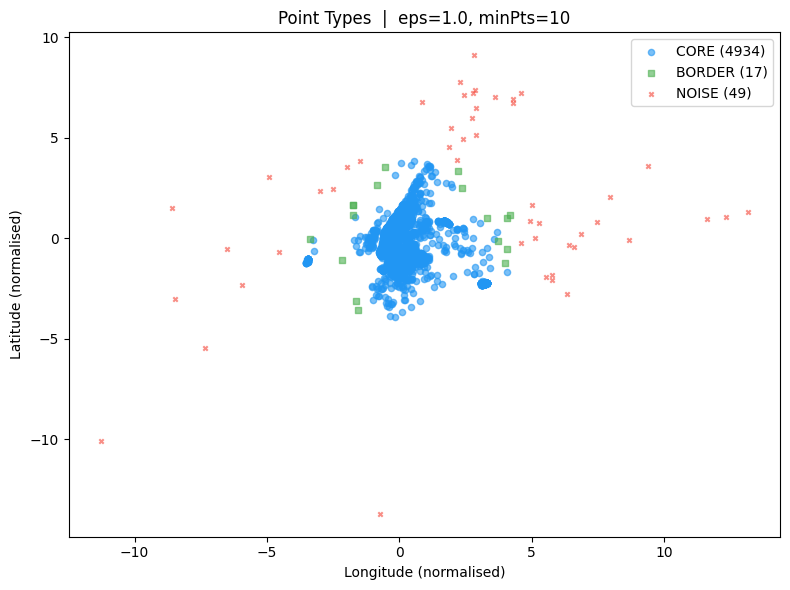

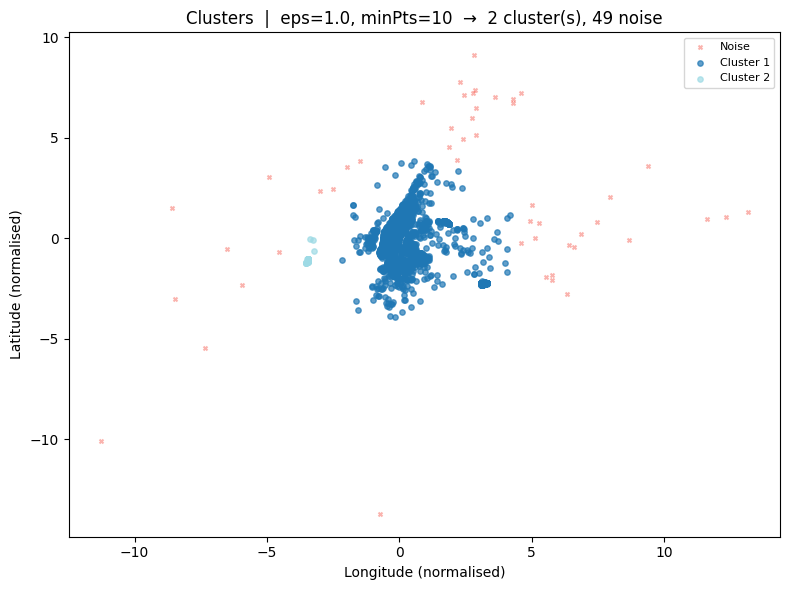

eps=1.0, minPts=20


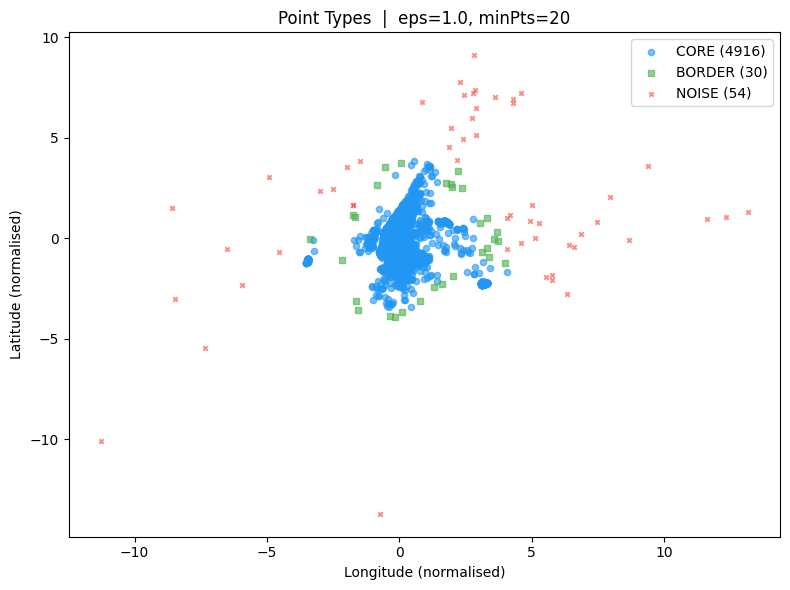

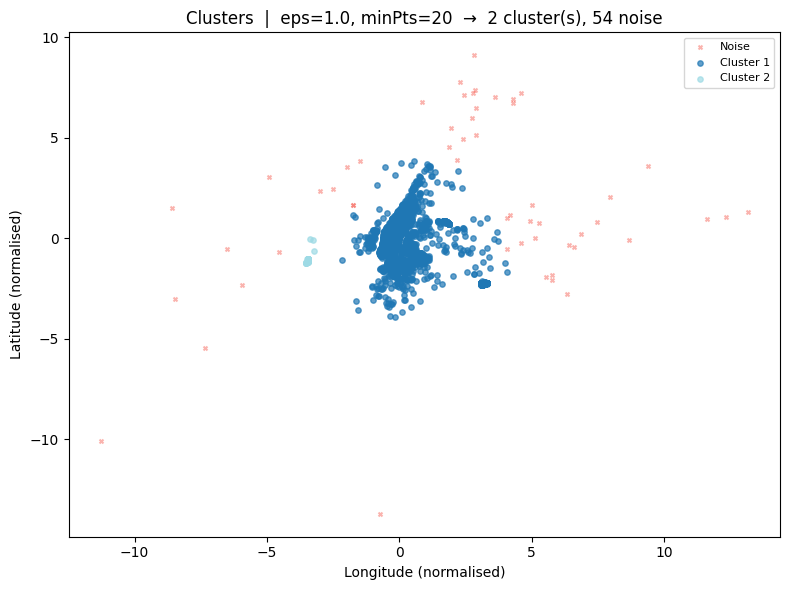

In [ ]:
eps_list = [0.1, 0.3, 0.5, 1.0]
mp_list  = [5, 10, 20]
results  = []

for eps in eps_list:
    for mp in mp_list:
        print(f'eps={eps}, minPts={mp}')
        model  = DBSCAN(eps=eps, min_pts=mp)
        labels = model.fit(X)
        types  = model.get_point_types(X, labels)

        results.append(dict(
            eps=eps, min_pts=mp,
            clusters = len(np.unique(labels[labels != -1])),
            core     = (types == 'CORE').sum(),
            border   = (types == 'BORDER').sum(),
            noise    = (labels == -1).sum()
        ))

        show_types(X, types, eps, mp)
        show_clusters(X, labels, eps, mp)

## 6. Summary

In [ ]:
summary = pd.DataFrame(results)
summary.columns = ['eps', 'minPts', 'Clusters', 'Core', 'Border', 'Noise']
summary

,eps,minPts,Clusters,Core,Border,Noise
0,0.1,5,23,4647,69,284
1,0.1,10,11,4412,143,445
2,0.1,20,10,4002,222,776
3,0.3,5,8,4862,29,109
4,0.3,10,6,4786,49,165
5,0.3,20,5,4689,104,207
6,0.5,5,3,4906,12,82
7,0.5,10,3,4871,36,93
8,0.5,20,3,4816,53,131
9,1.0,5,4,4952,19,29


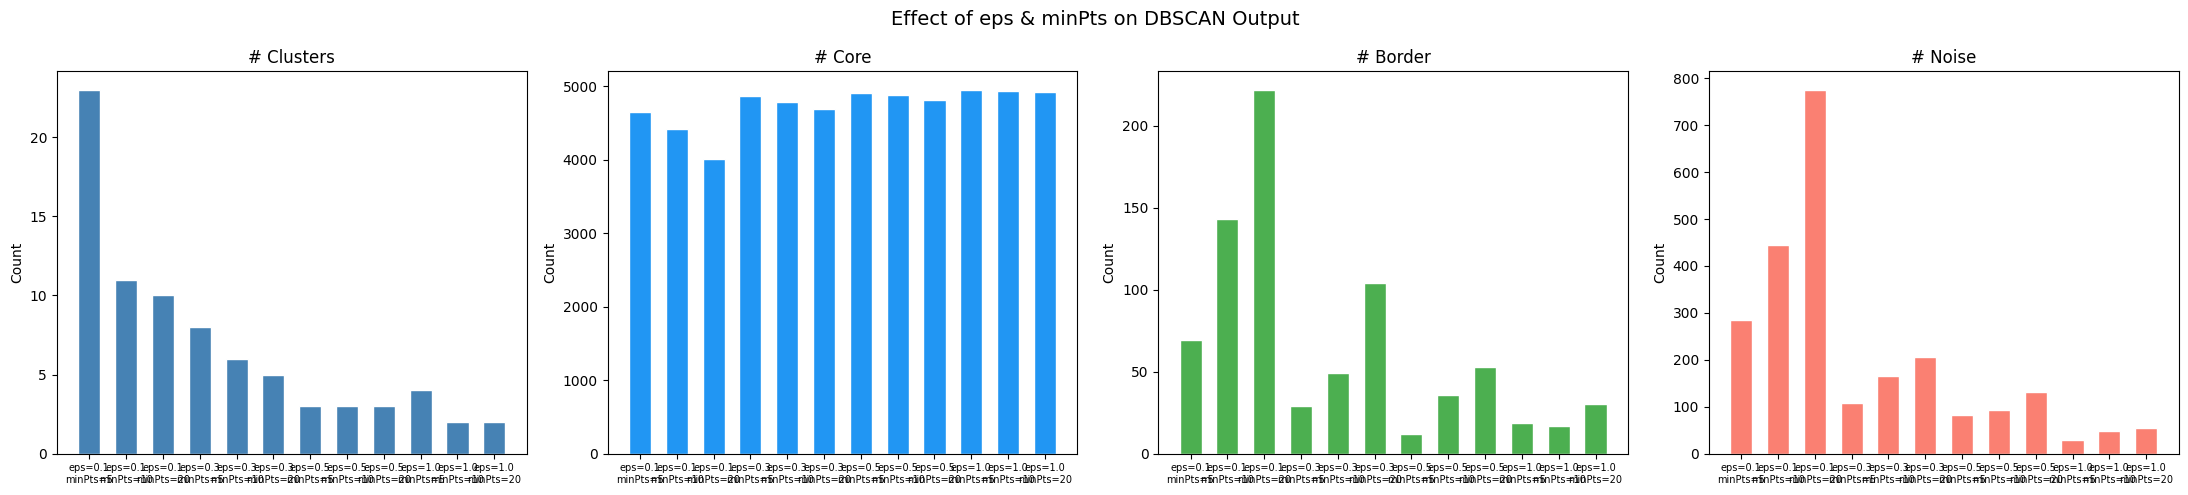

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
x_labels  = [f'eps={r.eps}\nminPts={r.minPts}' for r in summary.itertuples()]

for ax, col, color in zip(axes, ['Clusters', 'Core', 'Border', 'Noise'], ['steelblue', '#2196F3', '#4CAF50', 'salmon']):
    ax.bar(x_labels, summary[col].values, color=color, edgecolor='white', width=0.6)
    ax.set_title(f'# {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle('Effect of eps & minPts on DBSCAN Output', fontsize=14)
plt.tight_layout()
plt.show()